# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [1]:
source('../shared/r_funcs_repro.r')

# figure s3 vlz

- kernel: r_env, R 4.1.3
- date: 2024-02-21

## load

In [2]:
library(tidyverse)
library(tools)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)
library(igraph)
library(ggraph)
library(ComplexHeatmap)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

outdir <- '../../output/figs3'
create_dir(outdir)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.1.0
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘igraph’


The following objects are masked from ‘package:lubridate’:

    %--%, union


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘pa

In [3]:
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
gp <- 'response'

gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_lvls$response <- c('R', 'NR')
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

ctype_map <- list(
    'Tumor_Gp1' = c("Epi_M_CALML3"),
    'Tumor_Gp2' = c("Epi_M_CPS1", "Epi_M_MYBPC1", "Epi_M_PKP2", "Epi_M_SPRR3", "Epi_M_ACTL8", 'Epi_M_RNASE1'),
    'Epi_Normal' = c("Epi_A_IL1R2", "Epi_A_MGP", "Epi_N_LTF", "Epi_N_PIGR"),
    'Mixture' = c('Epi_T_Mix', 'Epi_B_Mix')
)
epi_gp_order <- c('Tumor_Gp1', 'Tumor_Gp2', 'Epi_Normal', 'Mixture')

## malignant cell ratio: s3a

In [4]:
f_obs <- '../../data/stage4/a01_data/h5ad/epi_obs.csv'
cutoff <- 0.02

In [5]:
# stat
df <- read_csv(file = f_obs, show_col_types = F) %>% 
    mutate(is_malig = if_else(infercnv_score >= cutoff, 'malig', 'non_malig')) %>% 
    count(cell_type, is_malig, name = 'n_cell_ctype_mtype') %>% 
    add_count(cell_type, wt = n_cell_ctype_mtype, name = 'n_cell_ctype') %>% 
    mutate(pct = 100 * n_cell_ctype_mtype / n_cell_ctype) %>% 
    pivot_wider(id_cols = 'cell_type', names_from = 'is_malig',
                values_from = 'pct', values_fill = 0)
df$epi_major <- df$cell_type
for (nm in names(ctype_map)) {
    df$epi_major[df$cell_type %in% ctype_map[[nm]]] <- nm
}
df %>% write_tsv(str_glue('{outdir}/figs3a-epi-malig_ratio.tsv'))

New names:
• `` -> `...1`


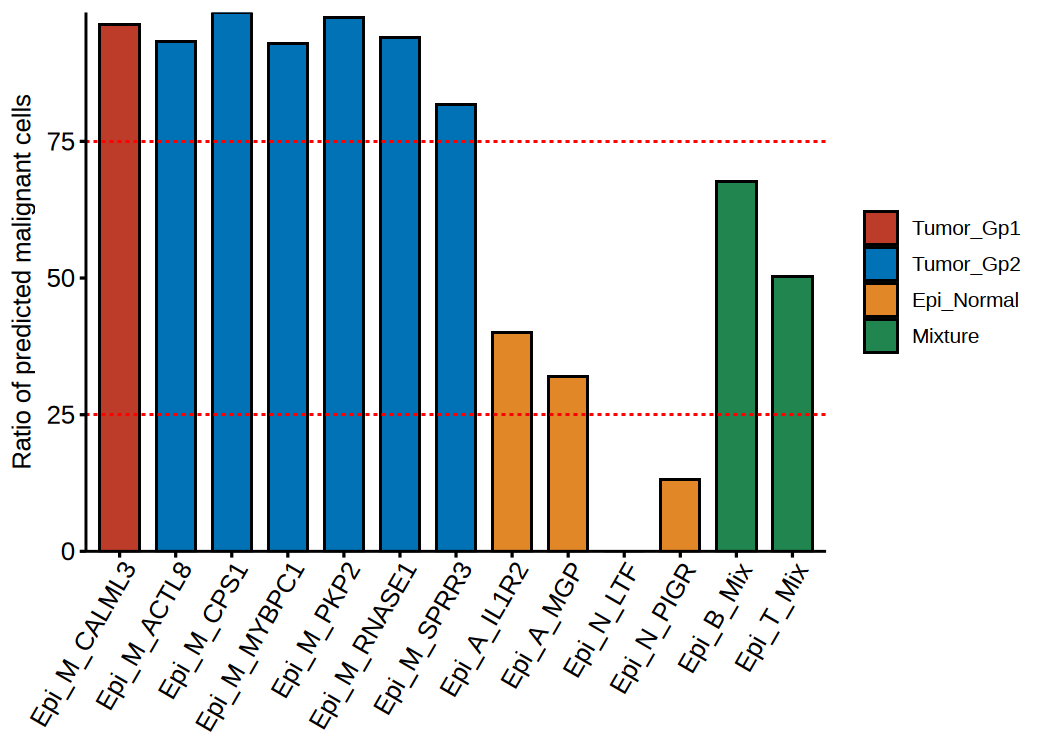

In [6]:
p <- read_tsv(str_glue('{outdir}/figs3a-epi-malig_ratio.tsv'), show_col_types = F) %>% 
    mutate(epi_major = factor(epi_major, levels = epi_gp_order)) %>%
    arrange(epi_major, cell_type) %>%
    ggbarplot(x = 'cell_type', y = 'malig', fill = 'epi_major', palette = 'nejm') +
    geom_hline(yintercept = c(25, 75), color = 'red', linetype = 'dashed') +
    scale_y_continuous(expand = c(0, NA)) +
    ylab('Ratio of predicted malignant cells') +
    theme(axis.title.x = element_blank(), axis.text.x = element_text(angle = 60, hjust = 0.98),
          legend.title = element_blank(), legend.position = 'right')
ggsave(filename = str_glue('{outdir}/figs3a-bar-epi_malig_ratio.pdf'), plot = p, width = 7, height = 5)
jp_opt(wd = 7, hg = 5)
print(p)


## epi cluster cell composition: s3b 

In [19]:
# require data from GEO
f_epi_obs <- '../../data/stage4/a01_data/h5ad/epi_obs.csv'
f_whole_obs <- '../../data/stage4/a01_data/h5ad/whole_obs.csv'

In [ ]:
# calculate cell composition
df_samp <- read_csv(f_whole_obs, show_col_types = F) %>% 
    count(sample, name = 'n_cell_samp')
df <- read_csv(f_epi_obs, show_col_types = F)

df <- cal_cell_comp(df_info = df, samp_cnt = df_samp, clinical_cols = 'patient') %>% 
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = c('patient_id', gp), merge_by = 'patient') %>%
    add_count(sample, name = 'n_cell_per_sample_epi', wt = freq)  # count epi cells for each sample

# add macro celltype
df$macrotype <- df$cell_type
for (nm in names(ctype_map)) {
    df$macrotype[df$cell_type %in% ctype_map[[nm]]] <- nm
}

# filter
df <- filter(df, !is.na(.data[[gp]]))
valid_ctypes <- df %>%
    summarise(.by = 'cell_type',
              n_nonzero = sum(pct != 0)) %>%
    filter(n_nonzero > 0) %>%
    pull(cell_type)
loginfo('%g/%g valid cell types', length(valid_ctypes), length(unique(df$cell_type)))
df <- filter(df, cell_type %in% valid_ctypes)
    

df %>% write_tsv(str_glue('{outdir}/figs3b-epi-cluster_cc-flt.tsv'))

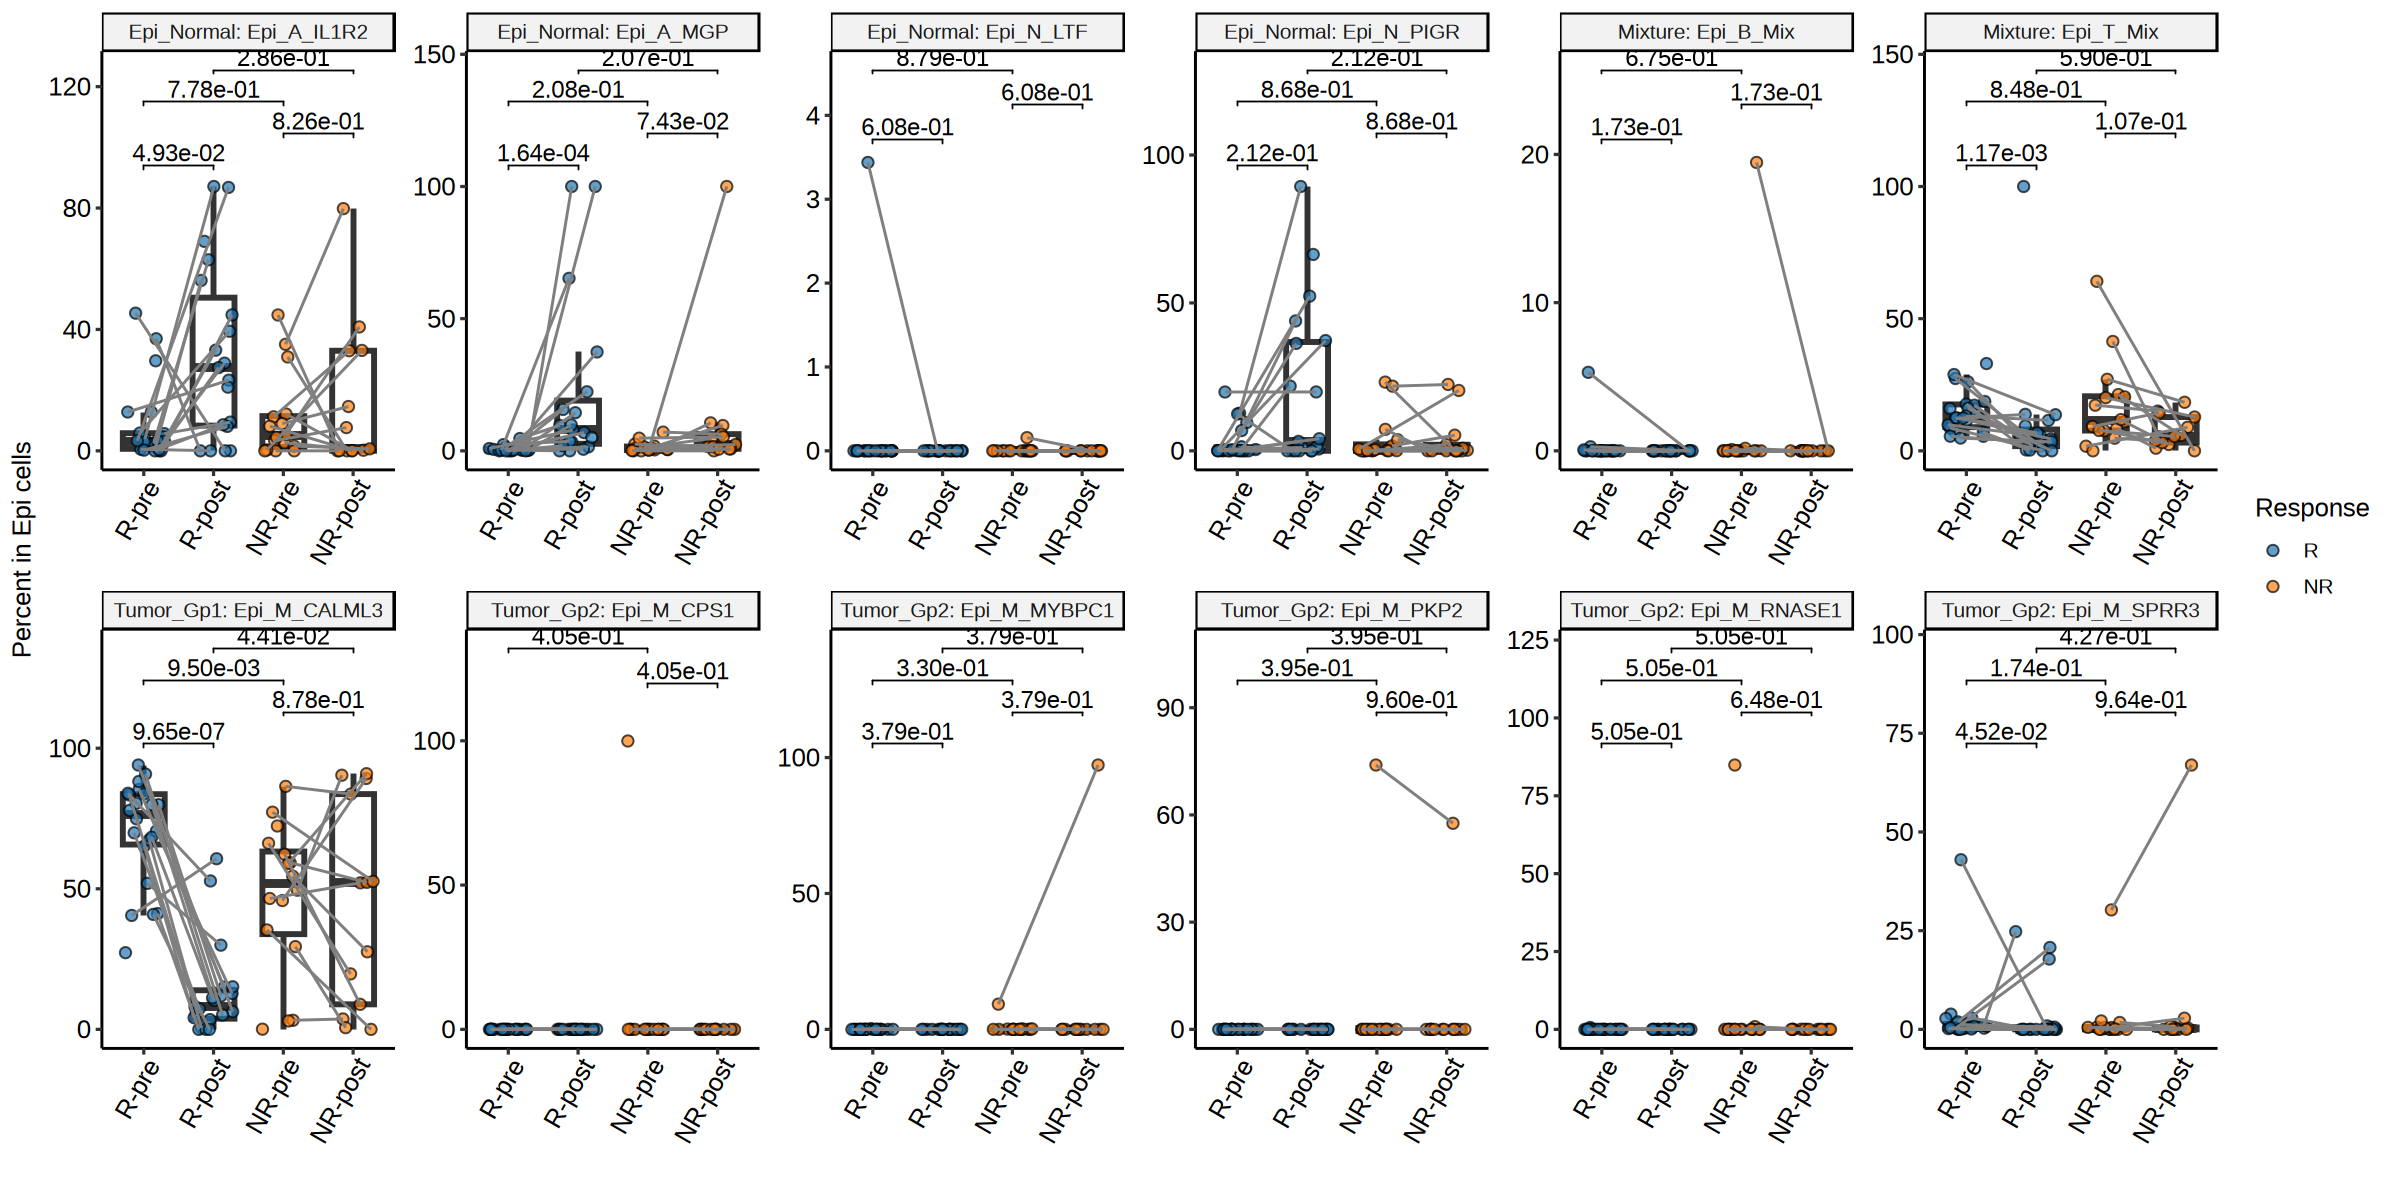

In [18]:
# plot
# all samples
p <- read_tsv(str_glue('{outdir}/figs3b-epi-cluster_cc-flt.tsv'), show_col_types = F) %>%
    mutate(cell_label = paste(macrotype, cell_type, sep = ': ')) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, xangle = 60, size = 2,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], facet_by = 'cell_label', ncol = 6) +
    labs(y = 'Percent in Epi cells', fill = 'Response') +
    theme(legend.position = 'right')
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_map[[gp]],
    x = 'plot_x', y = 'pct', facet_by = 'cell_label',
    stats_file = str_glue('{outdir}/figs3b-box_cc_in_epi-clusters-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs3b-box_cc_in_epi-clusters-all.pdf'), plot = p, width = 16, height = 8)
jp_opt(wd = 16, hg = 8)
print(p)


## communication compare v2: s3c

- date: 2024-02-23
- desc: use cellchat, sample by sample results; filtering criteria:
  - ligand/receptor should expressed in at least `min_cell` in source/target
  - interactio should detected in at least `min_sample_num` samples intra sample groups
  - filter out interactinos not significant in all samples intra sample groups
  - sample group by response+sample_type

In [9]:
f_all_comm <- '../../data/stage4/a21_cell_comm/ek_hk_major/analysis/v2-interactions-with_clin-full.tsv'

min_cell <- 50  # ligand/receptor should expressed in min_cell source/target cells
min_sample_num <- 3  # interaction should detected in these samples intra sample group
thresh <- 0.05  # significant threshold

ctype_rename_map <- c('Tumor_Gp1' = 'EK_tumor', 'Tumor_Gp2' = 'HK_tumor')
ctype_color <- c(
    'B & Plasma' = '#e71818', 'Tumor_Gp1' = '#317dbd', 'Endothelial' = '#46ae46',
    'Fibroblast' = '#9c4da5', 'Tumor_Gp2' = '#f79600', 'Myeloid' = '#f782bd', 'T cells' = '#bd9ece'
)

### preprocess

In [10]:
df_raw <- read_tsv(f_all_comm, show_col_types = F) %>%
    select(-c('mandard_group', 'response_degree', 'treatment_group', 'patient_gp', 'patient_gp_v2')) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>% 
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

for (nm in names(ctype_rename_map)) {
    df_raw$source[df_raw$source == ctype_rename_map[nm]] <- nm
    df_raw$target[df_raw$target == ctype_rename_map[nm]] <- nm
}
loginfo('total %g interactions, %g samples', nrow(df_raw), length(unique(df_raw$sample)))

2026-07-18 17:17:26.410178 INFO::these clinial info will be added: response
2026-07-18 17:17:27.669764 INFO::total 251965 interactions, 81 samples


In [11]:
# filtering
# discard Epi_Normal, Epi_others relevant pairs
df <- df_raw %>% 
    filter(!source %in% c('Epi_Norm', 'Epi_Others') & !target %in% c('Epi_Norm', 'Epi_Others'))
loginfo('discard Epi_Normal/other cells: %g pairs, %g samples', nrow(df), length(unique(df$sample)))

# filter by cell number
df <- df %>% 
    filter(n_cell_receptor_in_target_max >= min_cell, 
           n_cell_ligand_in_source_max >= min_cell)
loginfo('filter by cell number >= %g: %g records, %g samples',
        min_cell, nrow(df), length(unique(df$sample)))

# only samples with response
df_flt <- df %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]])
loginfo('samples with %s info: %g pairs, %g samples', gp, nrow(df_flt), length(unique(df_flt$sample)))

# filter by sample number
df_flt <- df_flt %>% 
    add_count(.data[[gp]], sample_type, source, target, interaction_name, name = 'n_sample') %>% 
    filter(n_sample >= min_sample_num)
loginfo('filter by sample number >= %g: %g records, %g samples',
        min_sample_num, nrow(df_flt), length(unique(df_flt$sample)))

# filter in-significant interactions
df_flt <- df_flt %>%
    summarise(.by = c(gp, 'sample_type', 'source', 'target', 'interaction_name'),
              p_min = min(pval)) %>%
    filter(p_min <= thresh) %>%
    select(.data[[gp]], sample_type, source, target, interaction_name) %>%
    merge(df_flt, by = c(gp, 'sample_type', 'source', 'target', 'interaction_name'))
loginfo('filter out in-significant interactions: %g records, %g samples',
        nrow(df_flt), length(unique(df_flt$sample)))

df_flt %>% write_tsv(str_glue('{outdir}/figs3c-cellchat_individual-flt_comm.tsv'), quote = 'needed')

2026-07-18 17:17:27.744657 INFO::discard Epi_Normal/other cells: 123150 pairs, 81 samples
2026-07-18 17:17:27.989877 INFO::filter by cell number >= 50: 95259 records, 81 samples
2026-07-18 17:17:28.008095 INFO::samples with response info: 79149 pairs, 70 samples
2026-07-18 17:17:28.128802 INFO::filter by sample number >= 3: 69965 records, 70 samples
2026-07-18 17:17:28.77206 INFO::filter out in-significant interactions: 67668 records, 70 samples


In [12]:
# summarise data to dataset (gp + sample_type)
df_stat <- df_flt %>% 
    summarise(.by = c(.data[[gp]], sample_type, 'source', 'target', 'interaction_name'),
              prob_agg = mean(prob)) %>%  # summarise for sample of each interaction
    add_count(.data[[gp]], sample_type, source, target, name = 'n_interaction') %>% 
    summarise(.by = c(gp, 'sample_type', 'source', 'target', 'n_interaction'),
              prob_mean = mean(prob_agg),
              prob_med = median(prob_agg)) # summarise for interaction 
loginfo('summarize to dataset: %g records', nrow(df_stat))
table(df_stat[[gp]], df_stat$sample_type, useNA = 'ifany')

df_stat %>% write_tsv(str_glue('{outdir}/figs3c-cellchat_individual-flt_comm-stat.tsv'))

2026-07-18 17:17:29.364421 INFO::summarize to dataset: 177 records


    
     post pre
  NR   47  44
  R    43  43

### vlz using prob mean diff

In [13]:
df_stat <- read_tsv(str_glue('{outdir}/figs3c-cellchat_individual-flt_comm-stat.tsv'), show_col_types = F)
edge_color_map <- c('R > NR' = 'red', 'R < NR' = 'blue')

coords <- as.matrix(data.frame(
    c(1.0000000, -0.2225209, -0.9009689, -0.9009689, -0.2225209, 0.6234898, 0.6234898),
    c(0.0000000, -0.9749279, 0.4338837, -0.4338837, 0.9749279, 0.7818315, -0.7818315)
))

In [14]:
# init net plot nodes
df_node <- data.frame(name = sort(unique(c(df_stat$source, df_stat$target))))
df_node$node_color <- NA
for (nm in names(ctype_color)) {
    df_node$node_color[df_node$name == nm] <- ctype_color[nm]
}
df_node %>% write_tsv(str_glue('{outdir}/figs3c-cellchat_individual-node_info.tsv'))

In [15]:
# calculate dataset diff
# pre: R vs NR
df_diff <- cal_edge_weight_diff(
    a = filter(df_stat, .data[[gp]] == 'R', sample_type == 'pre') %>% select(source, target, weight = prob_mean),
    b = filter(df_stat, .data[[gp]] == 'NR', sample_type == 'pre') %>% select(source, target, weight = prob_mean)
) %>%
    mutate(comp_type = 'Pre-treatment: R vs NR')
# post: R vs NR
df_diff <- cal_edge_weight_diff(
    a = filter(df_stat, .data[[gp]] == 'R', sample_type == 'post') %>% select(source, target, weight = prob_mean),
    b = filter(df_stat, .data[[gp]] == 'NR', sample_type == 'post') %>% select(source, target, weight = prob_mean)
) %>%
    mutate(comp_type = 'Post-treatment: R vs NR') %>% 
    rbind.data.frame(df_diff) %>% 
    mutate(weight_type = if_else(weight.diff > 0, 'R > NR', 'R < NR'))
df_diff %>% write_tsv(str_glue('{outdir}/figs3c-cellchat_individual-prob_mean_diff-R_vs_NR.tsv'))

2026-07-18 17:17:33.189385 INFO::a(43) - b(44) => 47 diff edges.
2026-07-18 17:17:33.21645 INFO::a(43) - b(47) => 47 diff edges.


agg_record_215923245 
                   2

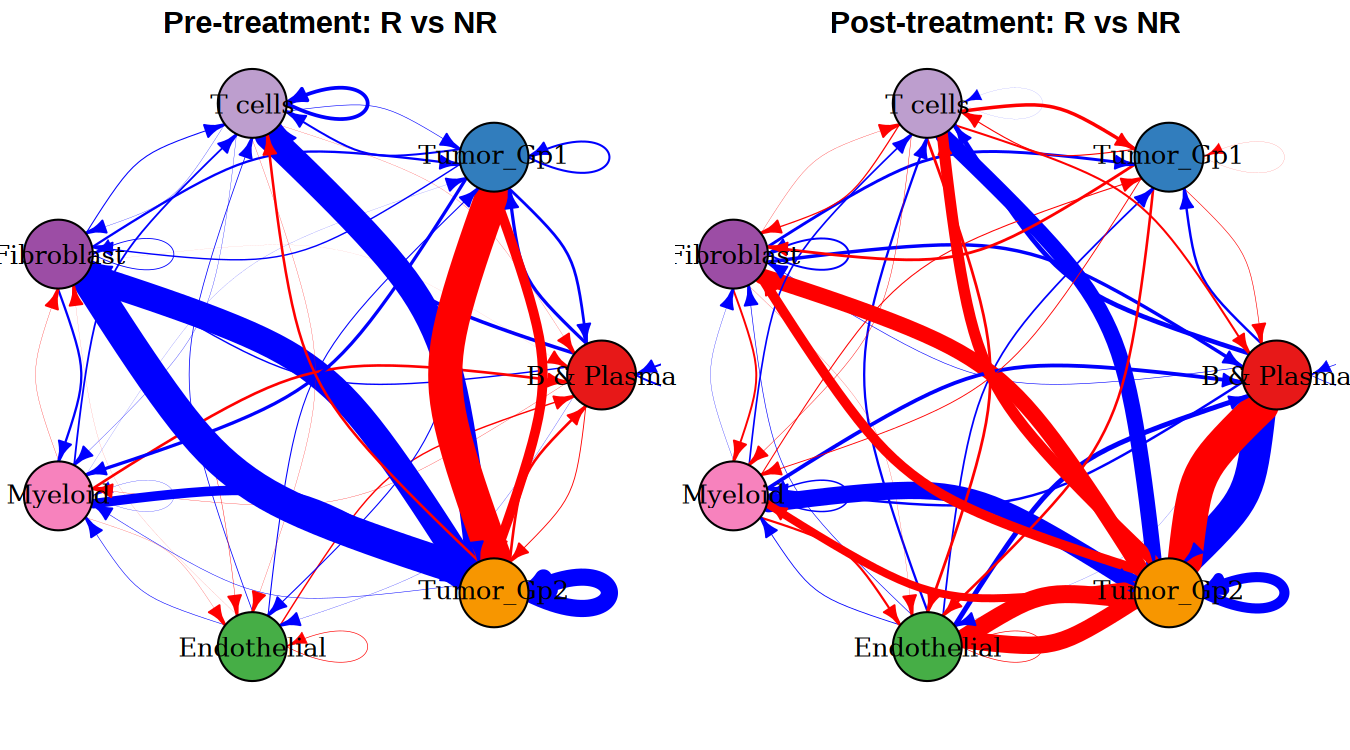

In [16]:
draw_cellchat_network <- function() {
    par(mfrow = c(1, 2), mar = c(1.5, 0, 1.5, 0.5))
    for (ctype in c('Pre-treatment: R vs NR', 'Post-treatment: R vs NR')) {
        df_edge <- df_diff %>%
            filter(comp_type == ctype) %>%
            select(source, target, weight, weight_type)
        df_edge$edge_color <- NA
        for (nm in names(edge_color_map)) {
            df_edge$edge_color[df_edge$weight_type == nm] <- edge_color_map[[nm]]
        }
        net <- graph_from_data_frame(d = df_edge, vertices = df_node, directed = T)
        plot(net,
             edge.arrow.size = 0.5,
             edge.curved = 0.4,
             edge.color = E(net)$edge_color,
             edge.width = get.edge.attribute(net, 'weight') * 200,
             vertex.size = 25,
             vertex.color = V(net)$node_color,
             vertex.label.color = 'black',
             vertex.label.cex = 1,
             layout = coords,
             main = ctype)
    }
}

pdf(str_glue('{outdir}/figs3c-cellchat_individual-prob_mean_diff-R_vs_NR.pdf'), width = 9, height = 5)
draw_cellchat_network()
dev.off()

jp_opt(wd = 9, hg = 5)
draw_cellchat_network()


## s3d: sample group

In [17]:
read_tsv('../../data/tables/full_clin_by_sample.tsv', show_col_types = F) %>% 
filter(data_type == 'single-cell') %>% 
count(patient_id, response_detail, mandard_grade) %>% 
count(response_detail, mandard_grade) %>% 
pivot_wider(names_from = response_detail, values_from = n, values_fill = 0) %>% 
arrange(mandard_grade) %>% 
select('mandard_grade', 'R', 'Gp1-', 'Gp1+', 'PR', 'NA')

mandard_grade,R,Gp1-,Gp1+,PR,NA
<dbl>,<int>,<int>,<int>,<int>,<int>
1,14,0,0,0,0
2,11,0,0,0,0
3,0,4,0,1,0
4,0,4,4,2,0
5,0,0,1,0,0
NA,0,0,0,0,11
